## 7. Implement transfer learning using pre-trained AlexNet, VGG16, ResNet50, and EfficientNetB0 models for image classification, and compare their performance. 


## Aim
Implement transfer learning using pretrained AlexNet, VGG16, ResNet50, and EfficientNetB0 for image classification and compare their performance.

## Problem and fair comparison
Compare four ImageNet-pretrained CNNs on CIFAR-10. Each backbone is frozen and only its final classifier is trained. All models use the same subset, input size, optimizer, batch size, and number of epochs.

PyTorch/torchvision is used because it provides official pretrained weights for all four requested architectures, including AlexNet. This is **feature-extraction transfer learning**; optional fine-tuning can unfreeze the last block in a separate experiment.

## Theory
Transfer learning reuses representations learned on a source task for a related target task. CNNs pretrained on ImageNet learn useful visual features. In feature extraction, pretrained parameters are frozen and a new task-specific classifier is trained, reducing the number of parameters updated.

## Architecture overview
- **AlexNet:** convolutional feature extraction followed by fully connected classifier layers.
- **VGG16:** stacks small convolution filters and uses a fully connected classifier.
- **ResNet50:** uses residual/skip connections and a final `fc` layer.
- **EfficientNetB0:** balances depth, width, and resolution; its output layer is in `classifier`.

## Dataset
CIFAR-10 contains ten image classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck. This notebook uses a seeded subset of 8,000 training images and 2,000 test images.

## Steps
1. Import dependencies and select CUDA when available.
2. Apply the preprocessing associated with the pretrained ResNet50 weights.
3. Load CIFAR-10 and select reproducible training and test subsets.
4. Load each pretrained model and replace its final classifier with a ten-class layer.
5. Freeze all parameters except the new classification head.
6. Train each head for three epochs.
7. Evaluate test accuracy.
8. Record accuracy, parameter counts, and elapsed training time.
9. Display the comparison table and charts.


## Step 1 — Import libraries and set the random seed and device

In [1]:

import copy
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


## Step 2 — Load and preprocess CIFAR-10

The preprocessing transform is taken from the default pretrained ResNet50 weights, using crop size 224 and resize size 232. A seeded NumPy generator selects the same-size subsets for all models.

In [2]:
# Pretrained-weight metadata supplies the preprocessing.
common_weights = models.ResNet50_Weights.DEFAULT
transform = common_weights.transforms(crop_size=224, resize_size=232)

full_train = datasets.CIFAR10("data", train=True, download=True, transform=transform)
full_test = datasets.CIFAR10("data", train=False, download=True, transform=transform)

rng = np.random.default_rng(SEED)
train_ids = rng.choice(len(full_train), 8000, replace=False)
test_ids = rng.choice(len(full_test), 2000, replace=False)

train_loader = DataLoader(
    Subset(full_train, train_ids), batch_size=64, shuffle=True,
    num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    Subset(full_test, test_ids), batch_size=64, shuffle=False,
    num_workers=2, pin_memory=True
)
class_names = full_train.classes
print("Classes:", class_names)


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Step 3 — Create the model builder

Load the default ImageNet weights, replace the appropriate final layer for ten classes, freeze every parameter, and then unfreeze only the replacement classifier.

In [3]:
def make_model(name, num_classes=10):
    if name == "AlexNet":
        model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    elif name == "VGG16":
        model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    elif name == "ResNet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == "EfficientNetB0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    else:
        raise ValueError(name)

    for parameter in model.parameters():
        parameter.requires_grad = False

    head = model.fc if name == "ResNet50" else model.classifier[-1]
    for parameter in head.parameters():
        parameter.requires_grad = True

    return model.to(device)


## Step 4 — Train the classifier head

Use cross-entropy loss and Adam with learning rate `1e-3`. The optimizer receives only trainable parameters. `model.eval()` keeps frozen backbone components, including BatchNorm and Dropout, in inference behaviour during head training.

In [4]:
def train_head(model, epochs=3):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
    )
    start = time.perf_counter()

    for epoch in range(epochs):
        # Keep the frozen backbone (including BatchNorm/Dropout) in inference mode.
        model.eval()
        correct = total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()

            correct += (logits.argmax(1) == labels).sum().item()
            total += len(labels)

        print(f"epoch {epoch+1}: train accuracy={correct/total:.3f}")

    return time.perf_counter() - start


## Step 5 — Evaluate on the test subset

Calculate accuracy as the proportion of correct predictions. Gradients are not needed during evaluation.

In [5]:
@torch.no_grad()
def evaluate(model):
    model.eval()
    correct = total = 0

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        correct += (model(images).argmax(1) == labels).sum().item()
        total += len(labels)

    return correct / total


## Step 6 — Run all four experiments

Each model is trained and evaluated sequentially. The table records test accuracy, total and trainable parameter counts in millions, and training duration in seconds.

In [6]:
rows = []
for name in ["AlexNet", "VGG16", "ResNet50", "EfficientNetB0"]:
    print()
    print(name)
    model = make_model(name)
    seconds = train_head(model, epochs=3)
    accuracy = evaluate(model)

    rows.append({
        "model": name,
        "test_accuracy": accuracy,
        "total_parameters_m": sum(p.numel() for p in model.parameters()) / 1e6,
        "trainable_parameters_m": sum(
            p.numel() for p in model.parameters() if p.requires_grad
        ) / 1e6,
        "train_seconds": seconds,
    })

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

comparison = pd.DataFrame(rows).sort_values("test_accuracy", ascending=False)
display(comparison.round(3))



AlexNet
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\Aksha/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:52<00:00, 4.68MB/s] 
C:\Users\Aksha\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 1: train accuracy=0.718
epoch 2: train accuracy=0.826
epoch 3: train accuracy=0.871

VGG16
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Aksha/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [01:59<00:00, 4.61MB/s] 


epoch 1: train accuracy=0.750
epoch 2: train accuracy=0.838
epoch 3: train accuracy=0.867

ResNet50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Aksha/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:15<00:00, 6.47MB/s]


epoch 1: train accuracy=0.778
epoch 2: train accuracy=0.883
epoch 3: train accuracy=0.906

EfficientNetB0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Aksha/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


URLError: <urlopen error [Errno 11001] getaddrinfo failed>

## Step 7 — Plot accuracy and training time

NameError: name 'comparison' is not defined

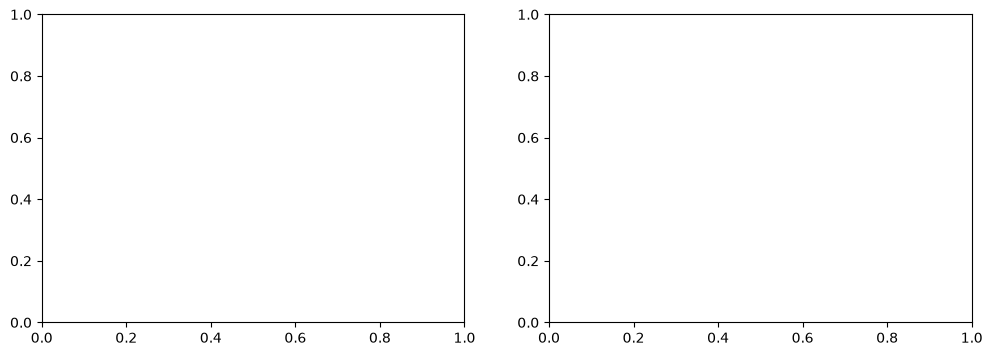

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

comparison.plot(
    x="model", y="test_accuracy", kind="bar", legend=False, ax=axes[0]
)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy")

comparison.plot(
    x="model", y="train_seconds", kind="bar",
    legend=False, ax=axes[1], color="orange"
)
axes[1].set_ylabel("Seconds")
axes[1].set_title("Training time")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## Step 8 — Results and discussion

Use the metrics printed by your run to discuss:

1. Differences and similarities in test accuracy across the four architectures.
2. Differences in training time in the runtime you used.
3. The distinction between total and trainable parameters: the backbones are frozen, so only the new classifier is optimized.
4. Architecture characteristics that may help contextualize the observations: AlexNet/VGG16 dense classifiers, ResNet residual connections, and EfficientNet compound scaling.
5. The limitations of using a subset of CIFAR-10 and only three epochs.

**Do not report guessed values.** The table and charts above are generated from the actual run. Timing varies with hardware and runtime conditions, and results may vary due to stochastic training.

## Optional extension
As a separate experiment, unfreeze the final backbone block and fine-tune it with a smaller learning rate (for example, `1e-5`). Keep those results separate from the frozen-backbone comparison.

## Conclusion
This experiment implements feature-extraction transfer learning with ImageNet-pretrained AlexNet, VGG16, ResNet50, and EfficientNetB0. Each model's final classifier is adapted to ten CIFAR-10 classes and trained while its pretrained backbone is frozen. Use the measured table and plots to summarize the observed accuracy and computational trade-offs.

## References
- PyTorch documentation: https://pytorch.org/docs/stable/index.html
- torchvision models: https://pytorch.org/vision/stable/models.html
- CIFAR-10 dataset: https://www.cs.toronto.edu/~kriz/cifar.html
